# GP-5 Обучение FCN для предсказания цены квартир

Продолжаем работу над датасетом, в прошлом ноутбуке мы обработали данные, теперь уже в этом ноутбуке обучим несколько полносвязных нейросетей для задачи регрессии: предсказание `price_rub`.

Используются:
- PyTorch;
- AdamW optimizer;
- learning rate scheduler;
- W&B для логирования экспериментов;
- несколько архитектур: простая MLP, MLP с BatchNorm/Dropout, Residual MLP.

Ожидается, что в папке с ноутбуком лежат файлы:

```text
X_train.csv
X_test.csv
y_train.csv
y_test.csv
```
Они так же есть в github репозитории.

## 1. Импорты

In [1]:
!pip install wandb -q

In [13]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

import wandb

## 2. Random seed и устройство

In [3]:
seed = 2026

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

## 3. Загрузка данных
Загружаем данные полученные в прошлом ноутбуке.


In [4]:
from google.colab import files

uploaded = files.upload()

Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [5]:
X_train_full = pd.read_csv("X_train.csv", index_col=0)
X_test = pd.read_csv("X_test.csv", index_col=0)

y_train_full = pd.read_csv("y_train.csv", index_col=0)["price_rub"]
y_test = pd.read_csv("y_test.csv", index_col=0)["price_rub"]

print("X_train_full:", X_train_full.shape)
print("X_test:", X_test.shape)
print("y_train_full:", y_train_full.shape)
print("y_test:", y_test.shape)

X_train_full: (17652, 504)
X_test: (4414, 504)
y_train_full: (17652,)
y_test: (4414,)


In [6]:
X_train_full

,rooms,area_sqm,metro_time_min,repair_type,build_year,is_long_rent,has_internet,has_air_conditioner,has_room_furniture,has_kitchen_furniture,...,metro_Южная,metro_Ясенево,metro_Яхромская,floor_ratio,is_first_floor,is_last_floor,is_skyscraper,has_images,is_high_floor,is_mid_rise_building
8600,0.088807,-0.007189,2.151624,-1.310570,-0.212929,0.256917,1,0,1,1,...,0,0,0,-0.409723,0,0,0,1,0,1
13456,0.088807,-0.003119,-0.127830,-0.053209,0.955423,0.256917,1,1,1,1,...,0,0,0,0.509462,0,0,0,1,0,0
12534,0.088807,-0.024176,-0.749499,-1.310570,-1.108666,0.256917,1,1,1,1,...,0,0,0,0.460717,0,0,0,1,0,1
20606,2.521112,0.293619,0.701062,1.204152,0.098631,0.256917,1,1,1,1,...,0,0,0,0.054512,0,0,0,1,0,1
14878,0.088807,-0.031962,1.529955,1.204152,1.033313,0.256917,1,1,1,1,...,0,0,0,0.704440,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6354,-1.127346,-0.033731,0.701062,-0.053209,-0.991831,0.256917,1,1,1,1,...,0,0,0,0.460717,0,0,0,1,0,1
7231,-1.127346,-0.037270,0.493839,1.204152,1.033313,0.256917,1,1,1,1,...,0,0,0,-0.931987,0,0,0,1,0,1
20231,2.521112,0.146754,-0.749499,1.204152,0.604917,0.256917,1,1,1,1,...,0,0,0,0.879616,0,0,1,1,1,0
10013,0.088807,-0.027538,-0.127830,-1.310570,-1.381281,0.256917,1,0,1,1,...,0,0,0,0.948163,0,0,0,1,1,0


In [7]:
y_train_full

,price_rub
8600,55000
13456,119900
12534,90000
20606,470000
14878,140000
...,...
6354,90000
7231,110000
20231,550000
10013,70000


## 4. Для PyTorch приводим признаки и таргет к float32

In [8]:
X_train_full = X_train_full.astype("float32")
X_test = X_test.astype("float32")

y_train_full = y_train_full.astype("float32")
y_test = y_test.astype("float32")

## 5. Train / Validation split

Из исходного `X_train` выделяем validation-выборку.  
`X_test` не трогаем до финальной оценки.


In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.15,
    random_state=2026
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (15004, 504)
X_val: (2648, 504)
X_test: (4414, 504)
y_train: (15004,)
y_val: (2648,)
y_test: (4414,)


## 6. Нормализация таргета

Признаки уже нормализованы в предыдущем ноутбуке.  
Для стабильного обучения нормализуем только целевую переменную `price_rub`.

Среднее и стандартное отклонение считаем только по `y_train`, а не по validation/test.


In [10]:
y_mean = y_train.mean()
y_std = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

print("y_mean:", y_mean)
print("y_std:", y_std)

y_mean: 119623.98
y_std: 140099.65625


## 7. PyTorch Dataset и DataLoader

Для удобства обучения сделаем даталоудеры

In [11]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_scaled.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_scaled.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

input_dim = X_train.shape[1]

input_dim

504

## 8. Метрики

Здесь напишем несколько вспомогательных функций.


In [14]:
def inverse_target(y_scaled):
    return y_scaled * y_std + y_mean


def calculate_metrics(y_true_scaled, y_pred_scaled):
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred) * 100
    }


def evaluate_model(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            y_pred = model(X_batch).cpu().numpy().ravel()

            preds.extend(y_pred)
            targets.extend(y_batch.numpy().ravel())

    return calculate_metrics(np.array(targets), np.array(preds))

# 9. Архитектуры моделей

Здесь сразу скажем, что будем использовать 3 различные архитектуры:
1. `SimpleMLP` - простая модель с 3 линейными слоями + ReLU.
2. `BNDropoutMLP` - 4 лин слоя + GELU (более сглаженный ReLU) + BatchNorm + Dropout.
3. `LNDropoutMLP` - тоже самое что 2, но только LayerNorm, а не BN.
4. `ResidualMLP` - модель состоящая из N=4... residual блоков (внутри каждого 2 лин слоя + GELU)

То есть в таком случае мы используем сразу несколько подходов к построению архитектуры, от самых примитивных, до более продвинутых. И сравним какие будут лучше.

## 9.1. Simple MLP

In [15]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

## 9.2. BatchNorm + Dropout MLP

In [16]:
class BNDropoutMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.08),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

## 9.3. LNDropoutMLP

Это тоже самое что вторая, но вместо батчнорма используем layernorm.

In [17]:
class LNDropoutMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.08),

            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

## 9.4. Residual MLP

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.15):
        super().__init__()

        self.block = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return x + self.block(x)


class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_blocks=4):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU()
        )

        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim) for _ in range(num_blocks)]
        )

        self.output_layer = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layer(x)
        return x

# 10. W&B

Будем логировать наше обучение в w&b.. Запустим `wandb.login()`


In [30]:
wandb.login()

True

# 11. Функция обучения

На каждой эпохе логируются:
- `train/loss`;
- `train/mae`, `train/rmse`, `train/r2`, `train/mape`;
- `val/mae`, `val/rmse`, `val/r2`, `val/mape`;
- `lr`.

Scheduler и early stopping работают по `val_mae`.


In [31]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)


def train_model_wandb(model, config):
    run = wandb.init(
        project="cian-apartment-rent-regression",
        name=config["model_name"],
        config=config,
        reinit="finish_previous"
    )

    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    loss_fn = nn.SmoothL1Loss()

    best_val_mae = float("inf")
    best_state = None
    patience_counter = 0

    history = []

    wandb.watch(model, log="gradients", log_freq=100)

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        train_metrics = evaluate_model(model, train_loader)
        val_metrics = evaluate_model(model, val_loader)

        scheduler.step(val_metrics["mae"])

        current_lr = optimizer.param_groups[0]["lr"]

        logs = {
            "epoch": epoch,
            "train/loss": train_loss,
            "train/mae": train_metrics["mae"],
            "train/rmse": train_metrics["rmse"],
            "train/r2": train_metrics["r2"],
            "train/mape": train_metrics["mape"],
            "val/mae": val_metrics["mae"],
            "val/rmse": val_metrics["rmse"],
            "val/r2": val_metrics["r2"],
            "val/mape": val_metrics["mape"],
            "lr": current_lr
        }

        wandb.log(logs, step=epoch)
        history.append(logs)

        print(
            f"{config['model_name']} | epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"train_mae={train_metrics['mae']:.0f} | "
            f"train_mape={train_metrics['mape']:.2f}% | "
            f"val_mae={val_metrics['mae']:.0f} | "
            f"val_mape={val_metrics['mape']:.2f}% | "
            f"val_r2={val_metrics['r2']:.4f} | "
            f"lr={current_lr:.6f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= config["early_stopping_patience"]:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    model_path = models_dir / f"{config['model_name']}.pt"
    torch.save(model.state_dict(), model_path)

    history_df = pd.DataFrame(history)
    history_path = models_dir / f"{config['model_name']}_history.csv"
    history_df.to_csv(history_path, index=False)

    wandb.save(str(model_path))
    wandb.save(str(history_path))

    wandb.summary["best_val_mae"] = best_val_mae
    wandb.summary["model_path"] = str(model_path)

    run.finish()

    return model, history_df, best_val_mae

# 12. Конфигурации экспериментов
Теперь создадим конфиги для обучения сразу всех 3 моделей.

In [32]:
experiments = [
    {
        "model_name": "simple_mlp",
        "model": SimpleMLP(input_dim),
        "epochs": 100,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "scheduler_patience": 6,
        "early_stopping_patience": 18
    },
    {
        "model_name": "bn_dropout_mlp",
        "model": BNDropoutMLP(input_dim),
        "epochs": 120,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "scheduler_patience": 7,
        "early_stopping_patience": 22
    },
    {
        "model_name": "ln_dropout_mlp",
        "model": LNDropoutMLP(input_dim),
        "epochs": 120,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "scheduler_patience": 7,
        "early_stopping_patience": 22
    },
    {
        "model_name": "residual_mlp",
        "model": ResidualMLP(input_dim, hidden_dim=256, num_blocks=4),
        "epochs": 140,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "scheduler_patience": 8,
        "early_stopping_patience": 25
    }
]

# 13. Обучение моделей

In [33]:
results = []
histories = {}

for experiment in experiments:
    config = {
        "model_name": experiment["model_name"],
        "epochs": experiment["epochs"],
        "lr": experiment["lr"],
        "weight_decay": experiment["weight_decay"],
        "early_stopping_patience": experiment["early_stopping_patience"],
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "loss": "SmoothL1Loss",
        "batch_size": batch_size,
        "input_dim": input_dim
    }

    model, history_df, best_val_mae = train_model_wandb(
        model=experiment["model"],
        config=config
    )

    histories[experiment["model_name"]] = history_df

    results.append({
        "model": experiment["model_name"],
        "best_val_mae": best_val_mae
    })

simple_mlp | epoch 001 | train_loss=0.1530 | train_mae=34414 | train_mape=25.41% | val_mae=37173 | val_mape=25.56% | val_r2=0.5200 | lr=0.001000
simple_mlp | epoch 002 | train_loss=0.0914 | train_mae=29675 | train_mape=21.22% | val_mae=32277 | val_mape=21.60% | val_r2=0.6318 | lr=0.001000
simple_mlp | epoch 003 | train_loss=0.0817 | train_mae=29980 | train_mape=24.06% | val_mae=33081 | val_mape=24.51% | val_r2=0.6386 | lr=0.001000
simple_mlp | epoch 004 | train_loss=0.0777 | train_mae=26529 | train_mape=17.80% | val_mae=30417 | val_mape=19.15% | val_r2=0.6543 | lr=0.001000
simple_mlp | epoch 005 | train_loss=0.0730 | train_mae=26993 | train_mape=20.42% | val_mae=30701 | val_mape=21.55% | val_r2=0.6762 | lr=0.001000
simple_mlp | epoch 006 | train_loss=0.0694 | train_mae=24767 | train_mape=16.81% | val_mae=28947 | val_mape=18.36% | val_r2=0.6817 | lr=0.001000
simple_mlp | epoch 007 | train_loss=0.0647 | train_mae=23599 | train_mape=16.26% | val_mae=28254 | val_mape=18.14% | val_r2=0.6956

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


simple_mlp | epoch 051 | train_loss=0.0251 | train_mae=13922 | train_mape=10.34% | val_mae=24984 | val_mape=17.03% | val_r2=0.7535 | lr=0.000016
Early stopping at epoch 51


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,███████████████████▄▄▄▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁
train/loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mae,█▆▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mape,▇█▅▆▄▄▃▃▃▃▃▂▃▂▃▃▃▂▂▁▁▃▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
train/r2,▂▁▁▂▃▅▆▆▇▇▇▇▇▇▇▇▇▇██████████████████████
train/rmse,███▇▆▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mae,█▅▆▄▄▃▂▃▂▂▂▂▂▂▂▁▁▂▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mape,█▇▃▅▃▂▃▂▂▂▂▂▁▃▃▂▃▃▃▁▁▁▃▂▁▂▂▁▂▂▂▁▁▂▁▁▂▁▁▁
val/r2,▁▄▄▅▆▆▇▇▇▇▇█▇▇▇█▇██▇████████████████████
+1,...


bn_dropout_mlp | epoch 001 | train_loss=0.1182 | train_mae=30416 | train_mape=21.36% | val_mae=33331 | val_mape=22.02% | val_r2=0.6094 | lr=0.000700
bn_dropout_mlp | epoch 002 | train_loss=0.0819 | train_mae=27622 | train_mape=20.93% | val_mae=31439 | val_mape=22.31% | val_r2=0.6746 | lr=0.000700
bn_dropout_mlp | epoch 003 | train_loss=0.0738 | train_mae=27699 | train_mape=20.88% | val_mae=30011 | val_mape=20.94% | val_r2=0.7036 | lr=0.000700
bn_dropout_mlp | epoch 004 | train_loss=0.0673 | train_mae=26774 | train_mape=18.83% | val_mae=29738 | val_mape=18.93% | val_r2=0.6744 | lr=0.000700
bn_dropout_mlp | epoch 005 | train_loss=0.0624 | train_mae=25609 | train_mape=18.31% | val_mae=29363 | val_mape=19.06% | val_r2=0.6927 | lr=0.000700
bn_dropout_mlp | epoch 006 | train_loss=0.0604 | train_mae=26008 | train_mape=20.17% | val_mae=28538 | val_mape=20.01% | val_r2=0.7243 | lr=0.000700
bn_dropout_mlp | epoch 007 | train_loss=0.0580 | train_mae=26565 | train_mape=20.31% | val_mae=28758 | val

...

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,████████████████▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mae,█▆▆▅▅▅▅▄▄▅▄▄▃▃▃▃▃▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mape,█▇▇▅▅▆▅▅▄▇▅▃▃▃▃▃▃▂▂▂▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/r2,▁▃▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████████████
train/rmse,█▇▆▆▆▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mae,█▅▅▄▃▅▄▃▃▄▃▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mape,▇▅▆▃▃▆▅▅▄█▄▂▂▂▂▂▂▁▂▁▂▁▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val/r2,▁▄▄▅▅▆▇▇▇▇▆▇█▇█▇██▇█▇██▇████▇▇▇▇▇▇██▇██▇
+1,...


residual_mlp | epoch 001 | train_loss=0.1183 | train_mae=35042 | train_mape=30.43% | val_mae=36851 | val_mape=30.02% | val_r2=0.6622 | lr=0.000700
residual_mlp | epoch 002 | train_loss=0.0801 | train_mae=29190 | train_mape=19.30% | val_mae=33050 | val_mape=20.16% | val_r2=0.6141 | lr=0.000700
residual_mlp | epoch 003 | train_loss=0.0730 | train_mae=25251 | train_mape=18.90% | val_mae=28828 | val_mape=19.80% | val_r2=0.7135 | lr=0.000700
residual_mlp | epoch 004 | train_loss=0.0654 | train_mae=26661 | train_mape=22.05% | val_mae=29833 | val_mape=22.70% | val_r2=0.7208 | lr=0.000700
residual_mlp | epoch 005 | train_loss=0.0616 | train_mae=24193 | train_mape=18.87% | val_mae=28432 | val_mape=19.91% | val_r2=0.7172 | lr=0.000700
residual_mlp | epoch 006 | train_loss=0.0609 | train_mae=33674 | train_mape=31.74% | val_mae=37056 | val_mape=32.22% | val_r2=0.7083 | lr=0.000700
residual_mlp | epoch 007 | train_loss=0.0586 | train_mae=21961 | train_mape=16.11% | val_mae=26607 | val_mape=17.11% |

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


residual_mlp | epoch 058 | train_loss=0.0169 | train_mae=13993 | train_mape=12.95% | val_mae=24846 | val_mape=16.51% | val_r2=0.7502 | lr=0.000001
Early stopping at epoch 58


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
lr,███████████▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▅▄▄▄▃▃▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mae,█▆▅▅▄▄▃▄▃▄▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/mape,█▄▅▂▃▂▂▄▄▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/r2,▁▁▃▃▄▅▅▅▅▅▆▅▆▆▇▇▇▇▇▇████████████████████
train/rmse,█▇█▇▇▆▆▅▆▄▄▄▄▅▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mae,█▆▄▃▂▃▄▄▂▁▂▂▂▁▂▂▂▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/mape,█▃▃▄▃▂▂▄▂▂▄▄▁▂▁▁▂▂▁▂▁▂▂▁▁▁▁▁▂▁▁▁▂▁▁▁▁▁▁▁
val/r2,▁▆▆▆▆▆▇▇█▇██▇▇▇▆▇▇▇▇█████████▇██████████
+1,...


# 14. Сравнение моделей по validation MAE

In [34]:
pd.DataFrame(results).sort_values("best_val_mae")

,model,best_val_mae
2,ln_dropout_mlp,24367.109375
3,residual_mlp,24504.935547
0,simple_mlp,24890.345703
1,bn_dropout_mlp,26200.701172


## 15. Переобучение?
Давайте посмотрим на изменение метрик `val_mae` и `train_mae`.


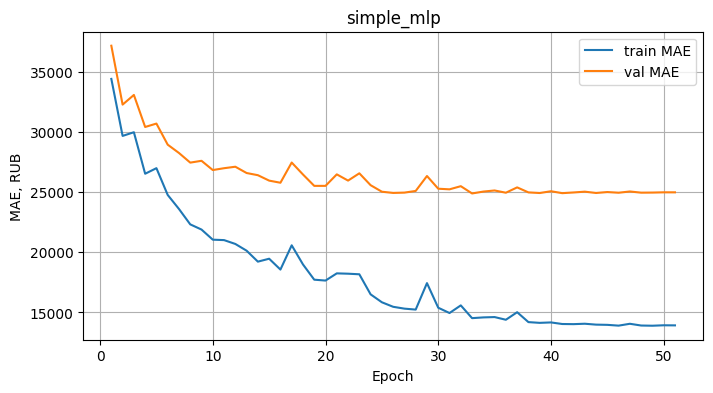

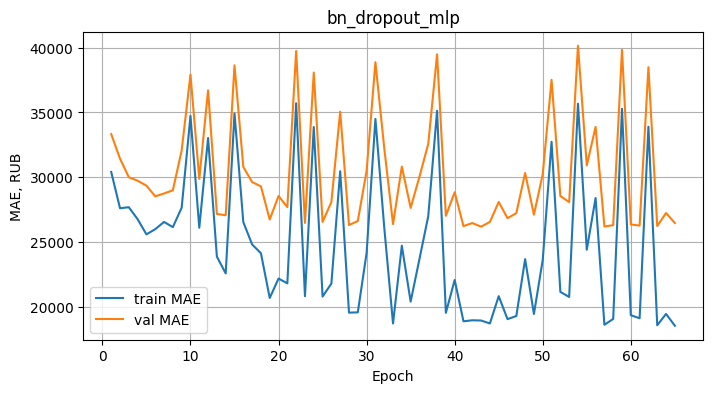

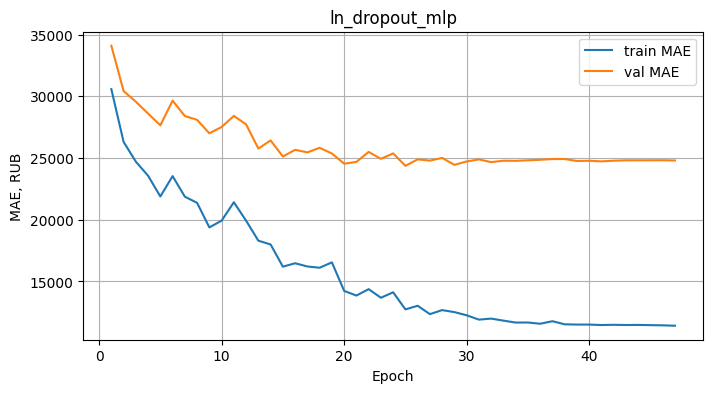

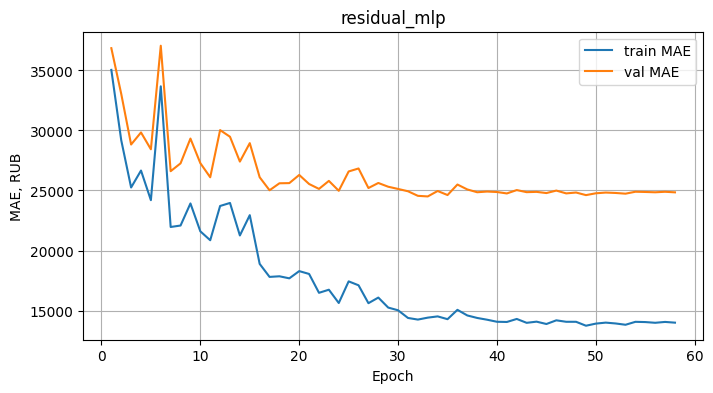

In [35]:
for model_name, history_df in histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train/mae"], label="train MAE")
    plt.plot(history_df["epoch"], history_df["val/mae"], label="val MAE")
    plt.title(model_name)
    plt.xlabel("Epoch")
    plt.ylabel("MAE, RUB")
    plt.legend()
    plt.grid()
    plt.show()

# 16. Финальная оценка на test

Давайте теперь оценим каждую модель на test.

In [42]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [43]:
model_classes = {
    "simple_mlp": SimpleMLP(input_dim),
    "bn_dropout_mlp": BNDropoutMLP(input_dim),
    "ln_dropout_mlp": LNDropoutMLP(input_dim),
    "residual_mlp": ResidualMLP(input_dim, hidden_dim=256, num_blocks=4)
}

test_results = []

for model_name, model in model_classes.items():
    model_path = models_dir / f"{model_name}.pt"
    total_params = count_parameters(model)

    model = model.to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    metrics = evaluate_model(model, test_loader)

    test_results.append({
        "model": model_name,
        "parameters": total_params,
        "test_mae": metrics["mae"],
        "test_rmse": metrics["rmse"],
        "test_r2": metrics["r2"],
        "test_mape": metrics["mape"]
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("test_mae").reset_index(drop=True)

test_results_df

,model,parameters,test_mae,test_rmse,test_r2,test_mape
0,residual_mlp,1200001,40920.652344,1.129974e+06,0.010487,15.613241
1,ln_dropout_mlp,171393,41194.628906,1.129675e+06,0.011011,16.188371
2,simple_mlp,72961,41237.746094,1.129504e+06,0.011310,16.736518
3,bn_dropout_mlp,171393,42457.644531,1.129804e+06,0.010784,17.583431


Здесь на самом деле ожидаемые значения: самая продвинутая (и большая) модель получает лучшие значения.

Более подробные выводы скажем в презентации, здесь все суховато.